In [1]:
import torch
from spectral import *
from source import SourceModule
import scipy
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR,CosineAnnealingWarmRestarts

In [2]:
domain_size=96
PMLsize=8
sigma_max=2
omega = 1
c0 = 1
source_location = [82, 48]
source_amplitude = 10
source_phase = 0
source_smoothing = False

In [4]:
sos = scipy.io.loadmat('/work/NeuralHelmholtz/sos1000.mat')
sos = sos['speeds_of_sound'][0]
sos = torch.from_numpy(sos).unsqueeze(0)
sos.shape

torch.Size([1, 1, 96, 96])

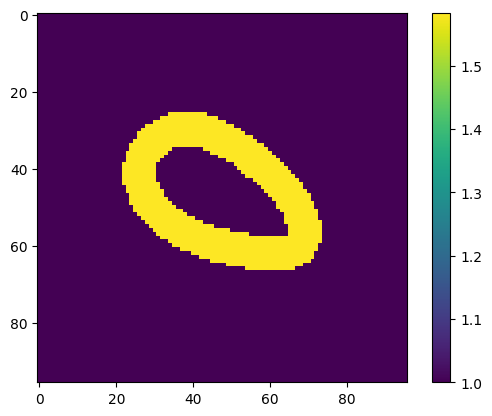

In [5]:
plt.imshow(sos.view(96,96))
plt.colorbar()

In [6]:
class learn_helm(nn.Module):
    def __init__(self,
                 domain_size,
                 omega,
                 PMLsize,
                 c0):
        super().__init__()
        self.omega = omega
        self.domain_size = domain_size
        self.PMLsize = PMLsize
        self.c0 = c0
        self.u = nn.Parameter(torch.zeros(1,2,96,96))
        self.lap_op = FastLaplacianWithPML(domain_size=domain_size,
                                            PMLsize=PMLsize,
                                            k=omega/c0,
                                            sigma_max=sigma_max)
        # self.k_sq = nn.Parameter((omega/self.sos)**2)
    def apply_lap(self, u:torch.Tensor):
        # u: 1*2*96*96
        return self.lap_op(u.permute(0, 2, 3, 1).contiguous()).permute(0, 3, 1, 2)
    
    def forward(self, sos, src):
        '''
        return Au - f
        '''
        return self.apply_lap(self.u) + ((self.omega/sos)**2)*self.u - src
    

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = learn_helm(domain_size=domain_size,
                   PMLsize=PMLsize,
                   omega=omega,
                   c0=c0).to(device)
print(f"u shape: {model.u.shape}")
sos = scipy.io.loadmat('/work/NeuralHelmholtz/sos1000.mat')
sos = sos['speeds_of_sound'][0]
sos = torch.from_numpy(sos).unsqueeze(0).to(device)
print(f"sos shape: {sos.shape}")
source_module = SourceModule(image_size=domain_size,
                             omega=omega,
                             location=source_location,
                             amplitude=source_amplitude,
                             phase=source_phase,
                             smooth=source_smoothing).to(device)
src = source_module.spatial_map(0).permute(0, 3, 1, 2).to(device)
print(f"src shape: {src.shape}")

u shape: torch.Size([1, 2, 96, 96])
sos shape: torch.Size([1, 1, 96, 96])
src shape: torch.Size([1, 2, 96, 96])


In [9]:
device

'cpu'

In [10]:
## train phase
optimizer = optim.Adam(model.parameters(),lr=0.001)
criterion = nn.MSELoss()
schedular = StepLR(optimizer,step_size=2500,gamma=0.5)
zeros = torch.zeros_like(src).to(device)
epochs = 10000
loss_list = []
for epoch in range(epochs):
    
    error = model(sos,src)
    loss = criterion(error,zeros)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    schedular.step()
    loss_list.append(loss.item())
    print(f"EPOCH: {epoch}, LOSS: {loss.item():.4e},LR: {schedular.get_last_lr()[0]}")

EPOCH: 0, LOSS: 5.4253e-03,LR: 0.001
EPOCH: 1, LOSS: 5.4065e-03,LR: 0.001
EPOCH: 2, LOSS: 5.4395e-03,LR: 0.001
EPOCH: 3, LOSS: 5.3933e-03,LR: 0.001
EPOCH: 4, LOSS: 5.3889e-03,LR: 0.001
EPOCH: 5, LOSS: 5.3716e-03,LR: 0.001
EPOCH: 6, LOSS: 5.3343e-03,LR: 0.001
EPOCH: 7, LOSS: 5.3121e-03,LR: 0.001
EPOCH: 8, LOSS: 5.3038e-03,LR: 0.001
EPOCH: 9, LOSS: 5.2872e-03,LR: 0.001
EPOCH: 10, LOSS: 5.2618e-03,LR: 0.001
EPOCH: 11, LOSS: 5.2416e-03,LR: 0.001
EPOCH: 12, LOSS: 5.2285e-03,LR: 0.001
EPOCH: 13, LOSS: 5.2142e-03,LR: 0.001
EPOCH: 14, LOSS: 5.1953e-03,LR: 0.001
EPOCH: 15, LOSS: 5.1765e-03,LR: 0.001
EPOCH: 16, LOSS: 5.1610e-03,LR: 0.001
EPOCH: 17, LOSS: 5.1469e-03,LR: 0.001
EPOCH: 18, LOSS: 5.1313e-03,LR: 0.001
EPOCH: 19, LOSS: 5.1147e-03,LR: 0.001
EPOCH: 20, LOSS: 5.0988e-03,LR: 0.001
EPOCH: 21, LOSS: 5.0842e-03,LR: 0.001
EPOCH: 22, LOSS: 5.0698e-03,LR: 0.001
EPOCH: 23, LOSS: 5.0549e-03,LR: 0.001
EPOCH: 24, LOSS: 5.0398e-03,LR: 0.001
EPOCH: 25, LOSS: 5.0251e-03,LR: 0.001
EPOCH: 26, LOSS: 5.011

KeyboardInterrupt: 

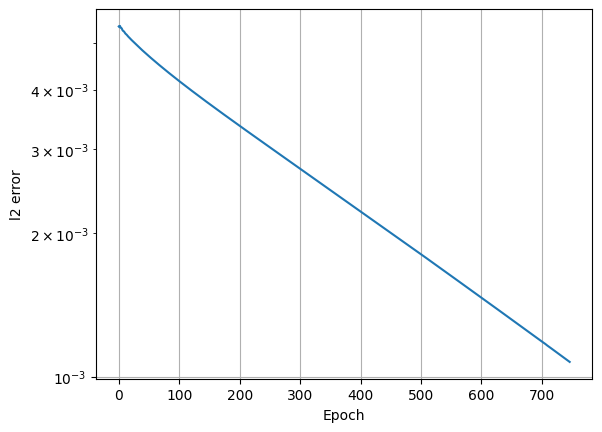

In [11]:
plt.semilogy(loss_list)
plt.xlabel('Epoch')
plt.ylabel('l2 error')
plt.grid()

In [12]:
u = torch.real(torch.view_as_complex(model.u.detach().cpu().permute(0,2,3,1).contiguous()))
u.shape

torch.Size([1, 96, 96])

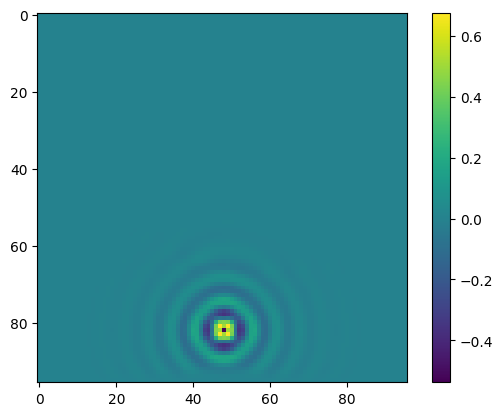

In [13]:
plt.imshow(u[0])
plt.colorbar()